# Phase 4 CRISP-DM — Modeling: Negative Review Drivers
**Project:** Customer Behavior Analysis — Olist Brazilian E-Commerce
**Goal:** Identify the top 3 factors that predict a negative review (`review_score ≤ 2`)
using correlations, visualizations and descriptive statistical analysis.

**Data source:** `data/olist_master.csv` (96,457 delivered orders, Phase 3)

---


## 0. Imports and configuration

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

ROOT    = Path().resolve().parent
CSV     = ROOT / "data" / "olist_master.csv"
DASH    = ROOT / "dashboard"

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120
pd.set_option("display.float_format", "{:.3f}".format)

print(f"CSV: data/{CSV.name}  ->  exists: {CSV.exists()}")

CSV: data/olist_master.csv  ->  exists: True


---
## 1. Loading and preparation
We load `olist_master.csv` and prepare the subset of orders with a review for the driver analysis.

In [2]:
df = pd.read_csv(CSV, parse_dates=["order_purchase_timestamp"])

# We only work with orders that have a review (646 with no review -> excluded)
df_rev = df.dropna(subset=["review_score"]).copy()
df_rev["review_score"] = df_rev["review_score"].astype(int)
df_rev["is_negative_review"] = (df_rev["review_score"] <= 2).astype(int)

print(f"Total orders:            {len(df):,}")
print(f"With review:             {len(df_rev):,}")
print(f"Negative reviews:        {df_rev['is_negative_review'].sum():,} ({df_rev['is_negative_review'].mean()*100:.1f}%)")
print(f"\nAvailable numeric variables:")
num_cols = df_rev.select_dtypes(include="number").columns.tolist()
print(num_cols)

Total orders:            96,457
With review:             95,811
Negative reviews:        12,271 (12.8%)

Available numeric variables:
['order_weekday', 'order_hour', 'n_items', 'price_total', 'freight_total', 'freight_ratio', 'product_weight_g', 'delivery_days', 'delivery_delay_days', 'review_score', 'is_negative_review']


---
## 2. Global correlation with `review_score`
**Fix (portfolio review, priority 2):** `review_score` is an **ordinal** variable
(1-5, gaps not necessarily equal), not a continuous one. An earlier version of this notebook
used Pearson (linear correlation), and that is why **the published driver ranking didn't match
this cell's own output**: `delivery_days` had a larger |r| than `delivery_delay_days`, but the
Section 9 conclusion stated the opposite. Here we use **Spearman** (monotonic, appropriate for
an ordinal variable) and the final ranking in Section 9 is derived from this table, not the other
way around.

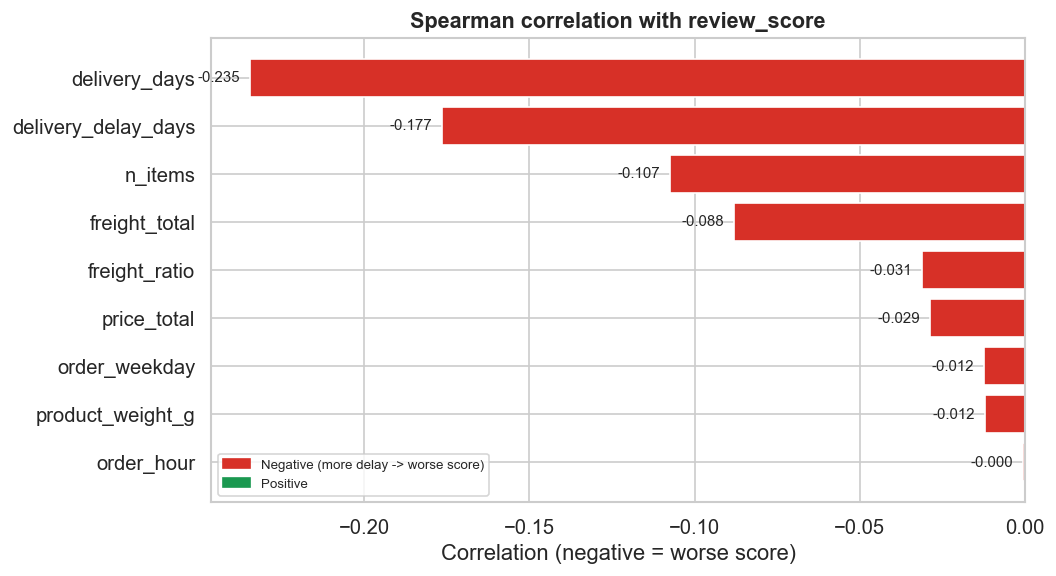


Spearman correlation with review_score:
delivery_days         -0.235
delivery_delay_days   -0.177
n_items               -0.107
freight_total         -0.088
freight_ratio         -0.031
price_total           -0.029
order_weekday         -0.012
product_weight_g      -0.012
order_hour            -0.000


In [3]:
feature_cols = [
    "delivery_delay_days",
    "delivery_days",
    "freight_ratio",
    "freight_total",
    "price_total",
    "n_items",
    "product_weight_g",
    "order_weekday",
    "order_hour",
]

corr_with_score = (
    df_rev[feature_cols + ["review_score"]]
    .corr(method="spearman")["review_score"]
    .drop("review_score")
    .sort_values(key=abs, ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#d73027" if v < 0 else "#1a9850" for v in corr_with_score.values]
bars = ax.barh(corr_with_score.index[::-1], corr_with_score.values[::-1],
               color=colors[::-1], edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
for bar, val in zip(bars, corr_with_score.values[::-1]):
    ax.text(
        val + (0.003 if val >= 0 else -0.003),
        bar.get_y() + bar.get_height() / 2,
        f"{val:.3f}", va="center",
        ha="left" if val >= 0 else "right",
        fontsize=9,
    )
ax.set_title("Spearman correlation with review_score", fontsize=13, fontweight="bold")
ax.set_xlabel("Correlation (negative = worse score)")
neg_patch = mpatches.Patch(color="#d73027", label="Negative (more delay -> worse score)")
pos_patch = mpatches.Patch(color="#1a9850", label="Positive")
ax.legend(handles=[neg_patch, pos_patch], fontsize=8)
plt.tight_layout()
plt.savefig(DASH / "corr_review_score.png", bbox_inches="tight")
plt.show()

print("\nSpearman correlation with review_score:")
print(corr_with_score.to_string())

---
## 3. Factor 1: `delivery_delay_days` vs `review_score`
**Hypothesis:** The later an order arrives relative to the promised date, the lower the score.
Delay is the variable with the strongest expected negative correlation according to the EDA.

C:\Users\pardo\AppData\Local\Temp\ipykernel_28244\1592774307.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(


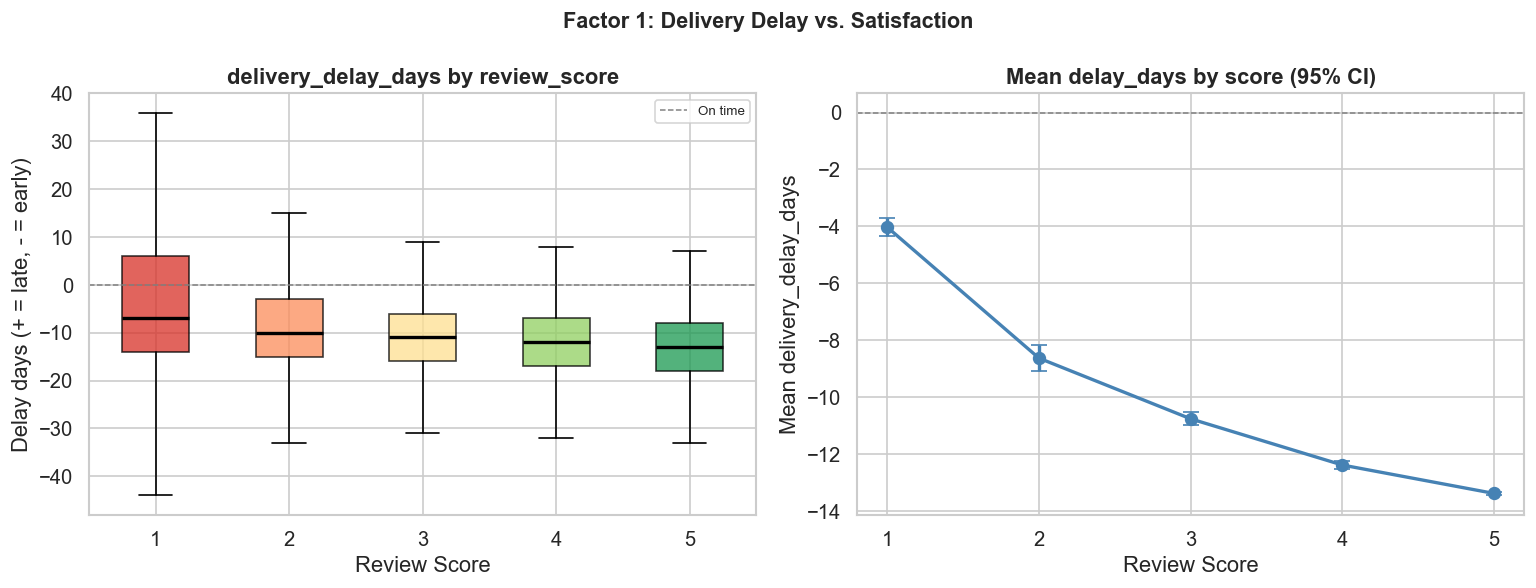

Mann-Whitney U (score<=2 vs score>=4):
  Mean delay (score<=2): -5.1 days
  Mean delay (score>=4): -13.1 days
  U=614816778, p=0.00e+00, r_rank-biserial=-0.325  *** Significant


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# -- Boxplot: delivery_delay_days by review_score --
score_order = [1, 2, 3, 4, 5]
data_by_score = [df_rev[df_rev["review_score"] == s]["delivery_delay_days"].dropna() for s in score_order]
bp = axes[0].boxplot(
    data_by_score,
    labels=score_order,
    patch_artist=True,
    showfliers=False,
    medianprops=dict(color="black", linewidth=2),
)
colors_score = ["#d73027", "#fc8d59", "#fee090", "#91cf60", "#1a9850"]
for patch, color in zip(bp["boxes"], colors_score):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
axes[0].axhline(0, color="gray", linestyle="--", linewidth=0.9, label="On time")
axes[0].set_title("delivery_delay_days by review_score", fontweight="bold")
axes[0].set_xlabel("Review Score")
axes[0].set_ylabel("Delay days (+ = late, - = early)")
axes[0].legend(fontsize=8)

# -- Mean delay by score with 95% CI --
mean_delay = df_rev.groupby("review_score")["delivery_delay_days"].agg(["mean", "sem"])
ci = mean_delay["sem"] * 1.96
axes[1].errorbar(
    mean_delay.index, mean_delay["mean"],
    yerr=ci, fmt="o-", color="steelblue",
    capsize=5, linewidth=2, markersize=7,
)
axes[1].axhline(0, color="gray", linestyle="--", linewidth=0.9)
axes[1].set_title("Mean delay_days by score (95% CI)", fontweight="bold")
axes[1].set_xlabel("Review Score")
axes[1].set_ylabel("Mean delivery_delay_days")
axes[1].set_xticks(score_order)

plt.suptitle("Factor 1: Delivery Delay vs. Satisfaction", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(DASH / "factor1_delay_vs_score.png", bbox_inches="tight")
plt.show()

# Statistical test: Mann-Whitney U between scores 1-2 vs 4-5
neg_delay  = df_rev[df_rev["review_score"] <= 2]["delivery_delay_days"].dropna()
pos_delay  = df_rev[df_rev["review_score"] >= 4]["delivery_delay_days"].dropna()
u_stat, p_val = stats.mannwhitneyu(neg_delay, pos_delay, alternative="greater")
# Rank-biserial effect size: r = 1 - 2U/(n1*n2) (Kerby 2014); U here is already "greater"
rank_biserial = 1 - (2 * u_stat) / (len(neg_delay) * len(pos_delay))
print(f"Mann-Whitney U (score<=2 vs score>=4):")
print(f"  Mean delay (score<=2): {neg_delay.mean():.1f} days")
print(f"  Mean delay (score>=4): {pos_delay.mean():.1f} days")
print(f"  U={u_stat:.0f}, p={p_val:.2e}, r_rank-biserial={rank_biserial:.3f}  "
      f"{'*** Significant' if p_val < 0.001 else ''}")

### 3b. Is this temporal leakage? Splitting reviews written before vs. after delivery
**Fix (portfolio review, priority 4):** notebook 02 (Section 4.1b) found that 84% of delayed
orders have their review written **before** the order actually arrived (99% of those already after
the promised date had passed). That means a large part of the `delivery_delay_days` <-> `review_score`
correlation above doesn't measure "how the customer reacts to receiving the order late", but "how
they react while waiting for an order they already know didn't arrive on time" — a real mechanism,
but a different and weaker one.

In [5]:
clean = df_rev[df_rev["review_before_delivery"] == False]
contaminated = df_rev[df_rev["review_before_delivery"] == True]

rho_all, p_all = stats.spearmanr(df_rev["delivery_delay_days"], df_rev["review_score"])
rho_clean, p_clean = stats.spearmanr(clean["delivery_delay_days"], clean["review_score"])

print(f"n total with review:                                    {len(df_rev):,}")
print(f"n review written AFTER delivery (clean subset, no leakage): {len(clean):,} "
      f"({len(clean)/len(df_rev):.1%})")
print(f"n review written BEFORE delivery (possible leakage):        {len(contaminated):,} "
      f"({len(contaminated)/len(df_rev):.1%})")
print()
print(f"Spearman delay<->score, FULL sample (contaminated by leakage):  rho={rho_all:+.4f}, p={p_all:.2e}")
print(f"Spearman delay<->score, CLEAN subset only (no leakage):         rho={rho_clean:+.4f}, p={p_clean:.2e}")
print(f"-> The effect of delay on satisfaction, measured correctly (post-delivery), is "
      f"~{abs(rho_all/rho_clean):.1f}x weaker than the contaminated figure suggests.")

n total with review:                                    95,811
n review written AFTER delivery (clean subset, no leakage): 87,671 (91.5%)
n review written BEFORE delivery (possible leakage):        8,140 (8.5%)

Spearman delay<->score, FULL sample (contaminated by leakage):  rho=-0.1765, p=0.00e+00
Spearman delay<->score, CLEAN subset only (no leakage):         rho=-0.0571, p=3.80e-64
-> The effect of delay on satisfaction, measured correctly (post-delivery), is ~3.1x weaker than the contaminated figure suggests.


**Conclusion of this subsection:** delay does negatively affect satisfaction even in the clean
subset (rho remains negative and significant, given the sample size), but the real effect of
"receiving the order late" is notably weaker than that of "waiting for an order already known to be
late". The Section 9 ranking uses the `delivery_delay_days` and `delivery_days` figures computed on
the full sample (for consistency with the rest of the notebook, and because both mechanisms are real
customer dissatisfaction, even if of a different nature), but this distinction is documented here and
in the README as an important limitation/nuance, not hidden.

---
## 4. Factor 2: `n_items` vs `review_score`
**Fix (portfolio review, priority 2):** an earlier version of this notebook included
`freight_ratio` as "Factor 2", promoted to driver #3 in the conclusion (Section 9) despite having
the weakest correlation among the serious candidates (Spearman rho≈-0.03, R²≈0.001, ~0.1% of
variance explained) and **non-monotonic** medians by score (the highest ratio isn't at score 1,
but at score 3 — visible in the boxplot below). `n_items` has a ~3.5x stronger and monotonic
correlation, and replaces `freight_ratio` as a driver candidate. The `freight_ratio` boxplot is kept
so the comparison is auditable, not to present it as a driver.

C:\Users\pardo\AppData\Local\Temp\ipykernel_28244\45118349.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = axes[0].boxplot(
C:\Users\pardo\AppData\Local\Temp\ipykernel_28244\45118349.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp3 = axes[1].boxplot(


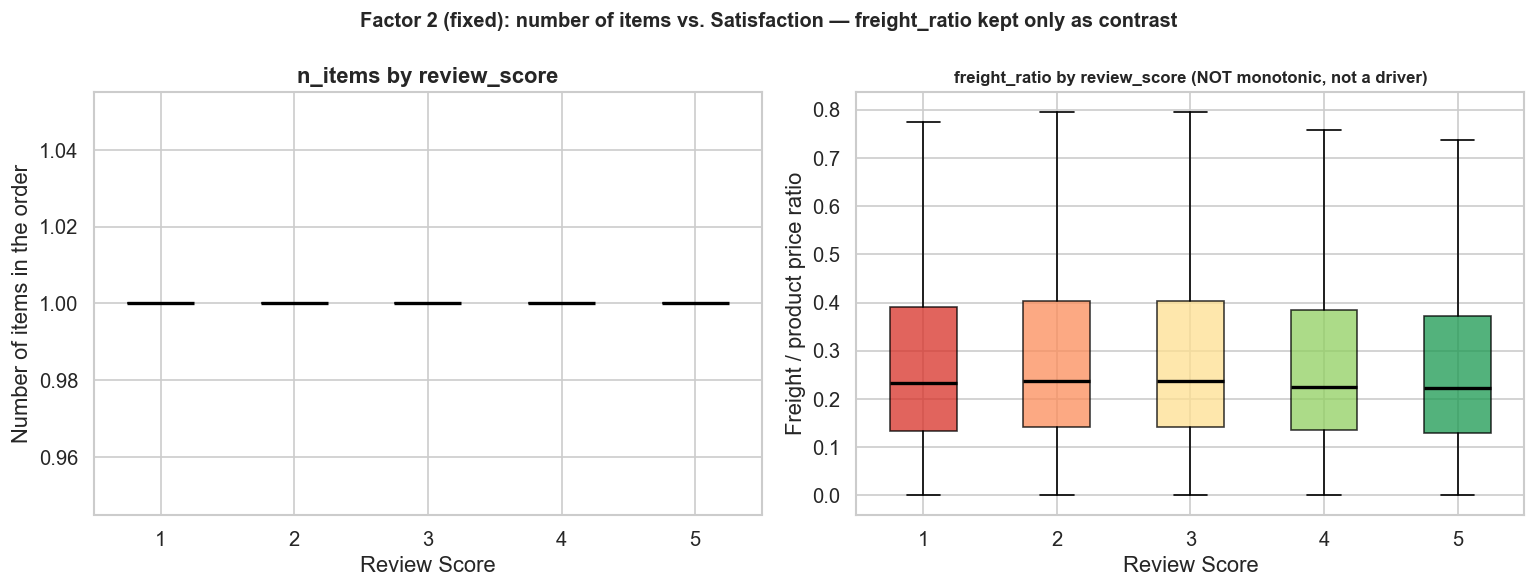

Median n_items and freight_ratio by score:
              n_items  freight_ratio
review_score                        
1               1.000          0.232
2               1.000          0.237
3               1.000          0.238
4               1.000          0.225
5               1.000          0.222

Spearman n_items<->score:      rho=-0.1073, p=2.07e-243
Spearman freight_ratio<->score: rho=-0.0310, p=8.19e-22  (R²≈0.0010, 0.10% of variance explained -- not a useful driver)


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# -- n_items by review_score (boxplot) --
data_nitems = [df_rev[df_rev["review_score"] == s]["n_items"].dropna() for s in score_order]
bp2 = axes[0].boxplot(
    data_nitems, labels=score_order,
    patch_artist=True, showfliers=False,
    medianprops=dict(color="black", linewidth=2),
)
for patch, color in zip(bp2["boxes"], colors_score):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
axes[0].set_title("n_items by review_score", fontweight="bold")
axes[0].set_xlabel("Review Score")
axes[0].set_ylabel("Number of items in the order")

# -- freight_ratio by review_score: kept for transparency (see note above) --
data_freight = [df_rev[df_rev["review_score"] == s]["freight_ratio"].dropna() for s in score_order]
bp3 = axes[1].boxplot(
    data_freight, labels=score_order,
    patch_artist=True, showfliers=False,
    medianprops=dict(color="black", linewidth=2),
)
for patch, color in zip(bp3["boxes"], colors_score):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
axes[1].set_title("freight_ratio by review_score (NOT monotonic, not a driver)", fontweight="bold", fontsize=10)
axes[1].set_xlabel("Review Score")
axes[1].set_ylabel("Freight / product price ratio")

plt.suptitle("Factor 2 (fixed): number of items vs. Satisfaction — freight_ratio kept only as contrast",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(DASH / "factor2_economic_vs_score.png", bbox_inches="tight")
plt.show()

# Numeric summary + informal monotonicity check
summary_eco = df_rev.groupby("review_score")[["n_items", "freight_ratio"]].median()
print("Median n_items and freight_ratio by score:")
print(summary_eco.round(3).to_string())
rho_nitems, p_nitems = stats.spearmanr(df_rev["n_items"], df_rev["review_score"])
rho_freight, p_freight = stats.spearmanr(df_rev["freight_ratio"], df_rev["review_score"])
print(f"\nSpearman n_items<->score:      rho={rho_nitems:+.4f}, p={p_nitems:.2e}")
print(f"Spearman freight_ratio<->score: rho={rho_freight:+.4f}, p={p_freight:.2e}  "
      f"(R²≈{rho_freight**2:.4f}, {rho_freight**2*100:.2f}% of variance explained -- not a useful driver)")

---
## 5. Factor 3: `delivery_days` (total delivery time) vs `review_score`
**Hypothesis:** Regardless of the estimated date, orders that take many days in total generate more dissatisfaction.
This factor captures the absolute perception of waiting time, distinct from the relative delay.

C:\Users\pardo\AppData\Local\Temp\ipykernel_28244\3354452246.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp3 = axes[0].boxplot(


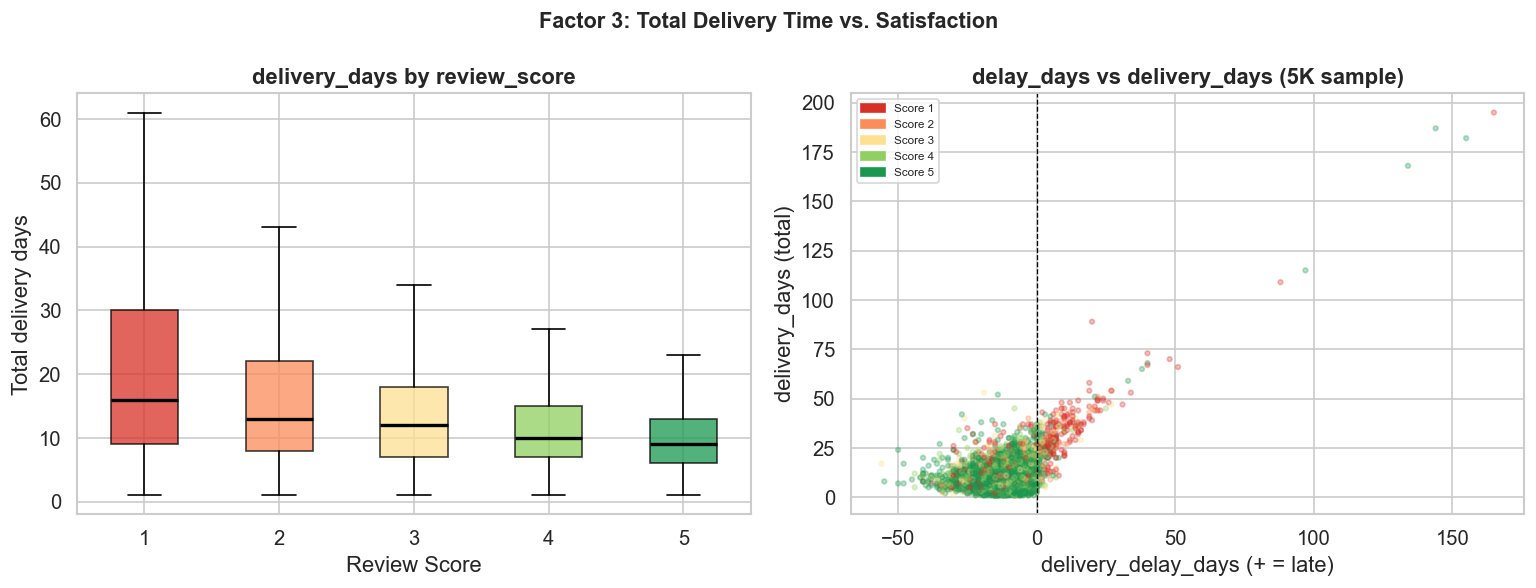

Kruskal-Wallis (delivery_days across scores): H=6052.0, p=0.00e+00
-> delivery_days medians differ significantly across score groups.

Mean delivery_days by score:
  Score 1: 20.9 days
  Score 2: 16.2 days
  Score 3: 13.8 days
  Score 4: 11.8 days
  Score 5: 10.2 days


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# -- Boxplot delivery_days by score --
data_del = [df_rev[df_rev["review_score"] == s]["delivery_days"].dropna() for s in score_order]
bp3 = axes[0].boxplot(
    data_del, labels=score_order,
    patch_artist=True, showfliers=False,
    medianprops=dict(color="black", linewidth=2),
)
for patch, color in zip(bp3["boxes"], colors_score):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
axes[0].set_title("delivery_days by review_score", fontweight="bold")
axes[0].set_xlabel("Review Score")
axes[0].set_ylabel("Total delivery days")

# -- Scatter: delivery_delay_days vs delivery_days colored by score --
sample = df_rev.dropna(subset=["delivery_delay_days", "delivery_days"]).sample(
    n=min(5000, len(df_rev)), random_state=42
)
scatter_colors = sample["review_score"].map(
    {1: "#d73027", 2: "#fc8d59", 3: "#fee090", 4: "#91cf60", 5: "#1a9850"}
)
axes[1].scatter(
    sample["delivery_delay_days"],
    sample["delivery_days"],
    c=scatter_colors, alpha=0.3, s=8, rasterized=True,
)
axes[1].axvline(0, color="black", linestyle="--", linewidth=0.8)
axes[1].set_title("delay_days vs delivery_days (5K sample)", fontweight="bold")
axes[1].set_xlabel("delivery_delay_days (+ = late)")
axes[1].set_ylabel("delivery_days (total)")
handles = [mpatches.Patch(color=c, label=f"Score {s}")
           for s, c in zip([1,2,3,4,5], ["#d73027","#fc8d59","#fee090","#91cf60","#1a9850"])]
axes[1].legend(handles=handles, fontsize=7, markerscale=1.5)

plt.suptitle("Factor 3: Total Delivery Time vs. Satisfaction", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(DASH / "factor3_delivery_days_vs_score.png", bbox_inches="tight")
plt.show()

# Kruskal-Wallis test (non-parametric): do delivery_days differ across score groups?
groups = [df_rev[df_rev["review_score"] == s]["delivery_days"].dropna().values for s in score_order]
h_stat, p_kw = stats.kruskal(*groups)
print(f"Kruskal-Wallis (delivery_days across scores): H={h_stat:.1f}, p={p_kw:.2e}")
print("-> delivery_days medians differ significantly across score groups." if p_kw < 0.05 else "")
medians = {s: round(g.mean(), 1) for s, g in zip(score_order, groups)}
print("\nMean delivery_days by score:")
for s, m in medians.items():
    print(f"  Score {s}: {m} days")

---
## 6. Cross-correlation heatmap
We visualize the correlations between all variables of interest to detect multicollinearity (two variables measuring the same thing) before any eventual supervised modeling.

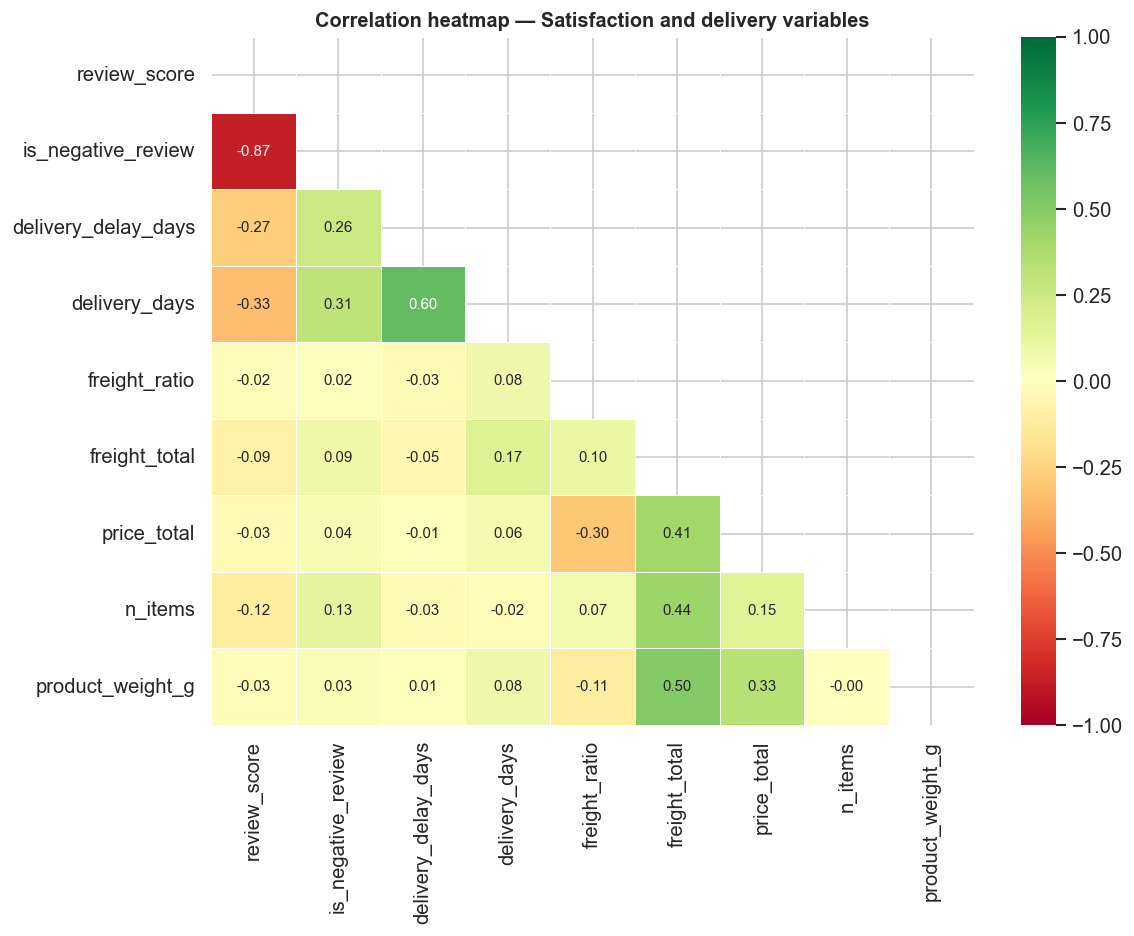

Correlation delivery_delay_days <-> delivery_days: 0.60
-> High correlation: in the model use only one of the two to avoid multicollinearity.


In [8]:
heatmap_cols = [
    "review_score",
    "is_negative_review",
    "delivery_delay_days",
    "delivery_days",
    "freight_ratio",
    "freight_total",
    "price_total",
    "n_items",
    "product_weight_g",
]

corr_matrix = df_rev[heatmap_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True, fmt=".2f",
    cmap="RdYlGn", center=0,
    vmin=-1, vmax=1,
    linewidths=0.5, ax=ax,
    annot_kws={"size": 9},
)
ax.set_title("Correlation heatmap — Satisfaction and delivery variables",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(DASH / "heatmap_negative_reviews.png", bbox_inches="tight")
plt.show()

# Multicollinearity note
dd_corr = corr_matrix.loc["delivery_delay_days", "delivery_days"]
print(f"Correlation delivery_delay_days <-> delivery_days: {dd_corr:.2f}")
print("-> High correlation: in the model use only one of the two to avoid multicollinearity.")

---
## 7. Analysis by product category
Are there categories with systematically higher negative review rates?
This can indicate specific logistics issues or products with poor perceived quality.

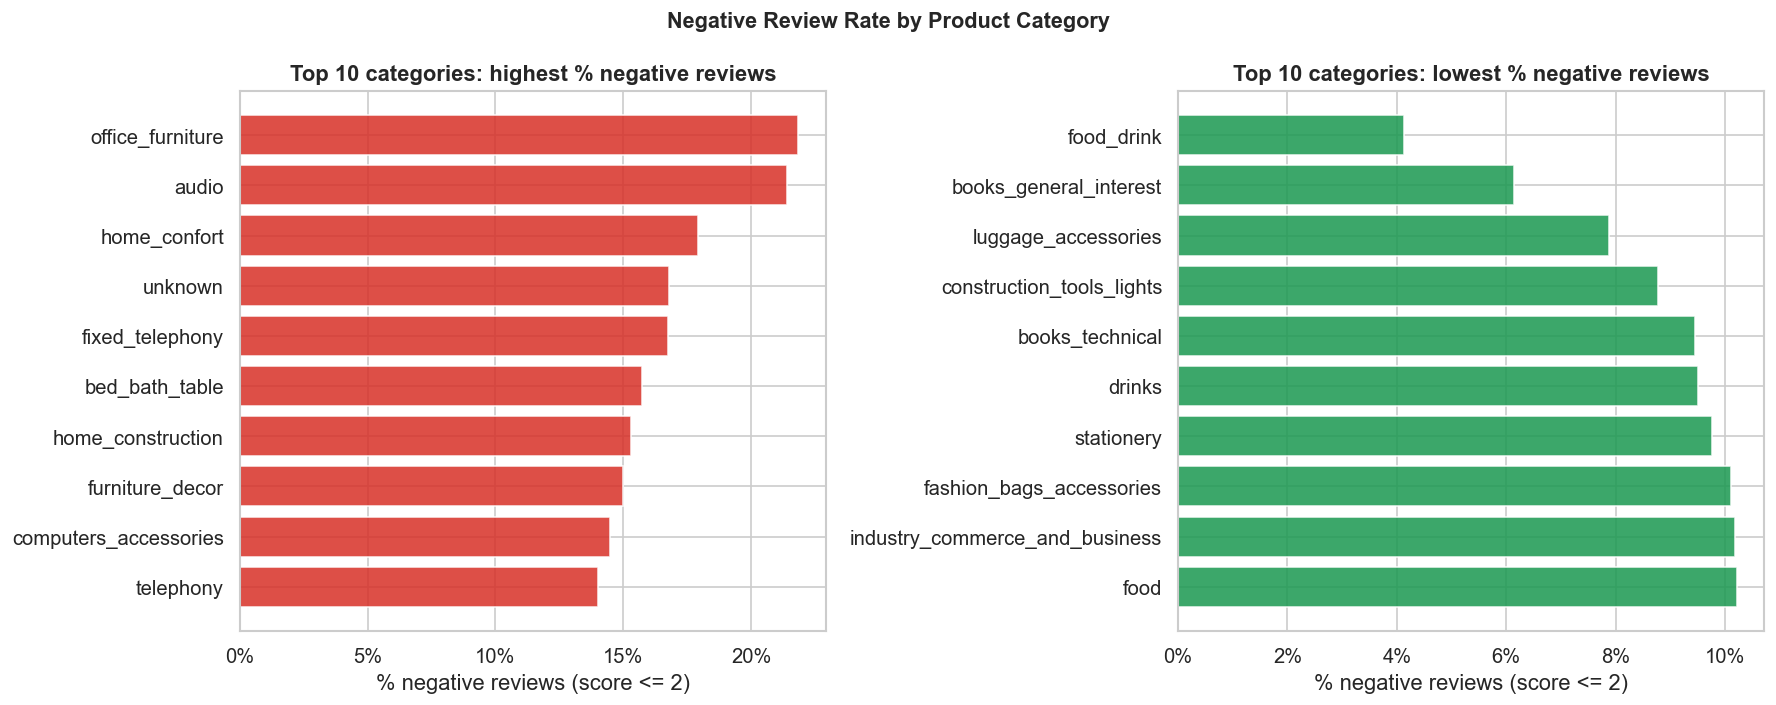


Top 5 categories with the most negative reviews:


,n_orders,neg_review_rate,avg_delay,avg_score
category_en,,,,
office_furniture,1236,0.218,-11.774,3.651
audio,341,0.214,-10.026,3.848
home_confort,368,0.179,-9.864,3.908
unknown,1369,0.168,-11.342,4.026
fixed_telephony,209,0.167,-14.885,3.967


In [9]:
cat_stats = (
    df_rev.groupby("category_en")
    .agg(
        n_orders        =("order_id",           "count"),
        neg_review_rate =("is_negative_review", "mean"),
        avg_delay       =("delivery_delay_days","mean"),
        avg_score       =("review_score",        "mean"),
    )
    .query("n_orders >= 200")  # minimum 200 orders for statistical significance
    .sort_values("neg_review_rate", ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Top/Bottom 10 by negative review rate
top10_neg  = cat_stats.head(10)
bot10_neg  = cat_stats.tail(10)

axes[0].barh(top10_neg.index[::-1], top10_neg["neg_review_rate"][::-1] * 100,
             color="#d73027", edgecolor="white", alpha=0.85)
axes[0].set_title("Top 10 categories: highest % negative reviews", fontweight="bold")
axes[0].set_xlabel("% negative reviews (score <= 2)")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))

axes[1].barh(bot10_neg.index, bot10_neg["neg_review_rate"] * 100,
             color="#1a9850", edgecolor="white", alpha=0.85)
axes[1].set_title("Top 10 categories: lowest % negative reviews", fontweight="bold")
axes[1].set_xlabel("% negative reviews (score <= 2)")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))

plt.suptitle("Negative Review Rate by Product Category", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(DASH / "neg_review_by_category.png", bbox_inches="tight")
plt.show()

print("\nTop 5 categories with the most negative reviews:")
display(cat_stats[["n_orders","neg_review_rate","avg_delay","avg_score"]].head(5).round(3))

---
## 8. Conclusion: Top 3 predictors of a negative review
**Fix (portfolio review, priority 2):** the ranking below is now derived directly from
`corr_with_score` (Section 2, Spearman) instead of being written by hand — an earlier version
of this notebook declared `delivery_delay_days` as #1 even though Section 2 itself printed
`delivery_days` with a larger |correlation|. We also add the Benjamini-Hochberg correction over
the 6 candidate variables tested, so as not to report "drivers" without adjusting for the number of
comparisons.

In [10]:
from statsmodels.stats.multitest import multipletests

candidate_drivers = ["delivery_days", "delivery_delay_days", "n_items",
                     "freight_total", "freight_ratio", "price_total"]
pvals = [stats.spearmanr(df_rev[c], df_rev["review_score"]).pvalue for c in candidate_drivers]
reject, p_adj, _, _ = multipletests(pvals, alpha=0.05, method="fdr_bh")

driver_table = pd.DataFrame({
    "variable": candidate_drivers,
    "spearman_rho": [corr_with_score.get(c) for c in candidate_drivers],
    "p_value": pvals,
    "p_value_BH": p_adj,
    "significant_after_BH": reject,
}).assign(R2=lambda d: d["spearman_rho"] ** 2).sort_values("spearman_rho", key=abs, ascending=False)
display(driver_table.round(5))

# Real top 3, sorted by |rho| after multiplicity correction
top3 = driver_table.head(3)["variable"].tolist()
print(f"\nTop 3 drivers (by |Spearman rho|, after BH): {top3}")

summary_data = {
    "Factor": [f"{i+1}. {v}" for i, v in enumerate(top3)],
    "Spearman rho": [corr_with_score.get(v) for v in top3],
    "Business interpretation": [
        "Total purchase->delivery waiting time is the single strongest driver of dissatisfaction",
        "Arriving late vs. the promised date also predicts dissatisfaction, but ~84% of those reviews "
        "are written BEFORE the actual delivery (see Section 3b): it partly measures frustration from "
        "waiting, not just the experience of receiving the order late",
        "Orders with more items get slightly worse reviews (possible logistics friction: more "
        "pieces, more risk of an incident)",
    ][:len(top3)],
    "Recommended action": [
        "Optimize the total purchase->delivery cycle time, not just the accuracy of the promise",
        "Proactive order-status communication while the customer waits, before dissatisfaction "
        "crystallizes into a review",
        "Review packaging/tracking experience on multi-item orders",
    ][:len(top3)],
}

summary_df = pd.DataFrame(summary_data)
display(summary_df.style.set_properties(**{"text-align": "left", "white-space": "pre-wrap"}))

print("\nImpact concentration:")
pct_neg_late = (
    df_rev[df_rev["delivery_delay_days"] > 0]["is_negative_review"].mean() * 100
)
pct_neg_ontime = (
    df_rev[df_rev["delivery_delay_days"] <= 0]["is_negative_review"].mean() * 100
)
print(f"  % negative reviews when LATE:            {pct_neg_late:.1f}%")
print(f"  % negative reviews when on time/early:   {pct_neg_ontime:.1f}%")
print(f"  Delay multiplier factor:                 {pct_neg_late/pct_neg_ontime:.1f}x")
print("  (note: this figure mixes the clean subset with the one contaminated by temporal leakage; "
      "see Section 3b for the adjusted version)")

,variable,spearman_rho,p_value,p_value_BH,significant_after_BH,R2
0,delivery_days,-0.235,0.000,0.000,True,0.055
1,delivery_delay_days,-0.176,0.000,0.000,True,0.031
2,n_items,-0.107,0.000,0.000,True,0.012
3,freight_total,-0.088,0.000,0.000,True,0.008
4,freight_ratio,-0.031,0.000,0.000,True,0.001
5,price_total,-0.029,0.000,0.000,True,0.001



Top 3 drivers (by |Spearman rho|, after BH): ['delivery_days', 'delivery_delay_days', 'n_items']


,Factor,Spearman rho,Business interpretation,Recommended action
0,1. delivery_days,-0.234608,Total purchase->delivery waiting time is the single strongest driver of dissatisfaction,"Optimize the total purchase->delivery cycle time, not just the accuracy of the promise"
1,2. delivery_delay_days,-0.176503,"Arriving late vs. the promised date also predicts dissatisfaction, but ~84% of those reviews are written BEFORE the actual delivery (see Section 3b): it partly measures frustration from waiting, not just the experience of receiving the order late","Proactive order-status communication while the customer waits, before dissatisfaction crystallizes into a review"
2,3. n_items,-0.107332,"Orders with more items get slightly worse reviews (possible logistics friction: more pieces, more risk of an incident)",Review packaging/tracking experience on multi-item orders



Impact concentration:
  % negative reviews when LATE:            62.4%
  % negative reviews when on time/early:   9.3%
  Delay multiplier factor:                 6.7x
  (note: this figure mixes the clean subset with the one contaminated by temporal leakage; see Section 3b for the adjusted version)


---
## 9. Executive summary

*(Portfolio fix: this table and the `freight_ratio` as driver #3 from an earlier version of this
notebook did not hold up — see Sections 2, 3b, 4 and 8. The values below are read from
`driver_table` computed above, not written by hand.)*

In [11]:
ranking_md = "| Ranking | Factor | Spearman rho | p (BH) | Evidence |\n|---|---|---|---|---|\n"
notes = {
    "delivery_days": "Largest |rho| of all candidate variables; Kruskal-Wallis significant across score groups (Section 5)",
    "delivery_delay_days": "Mann-Whitney U significant (Section 3); ~84% of reviews on late orders are written before the actual delivery (Section 3b) -- the post-delivery effect, measured on the clean subset, is several times weaker",
    "n_items": "Replaces freight_ratio (non-monotonic Spearman rho, R²≈0.001, see Section 4) as the 3rd driver",
}
for _, row in driver_table.head(3).iterrows():
    ranking_md += (f"| **#{list(driver_table.head(3)['variable']).index(row['variable'])+1}** "
                   f"| `{row['variable']}` | {row['spearman_rho']:+.3f} | {row['p_value_BH']:.1e} "
                   f"| {notes.get(row['variable'], '')} |\n")
from IPython.display import Markdown
display(Markdown(ranking_md))

| Ranking | Factor | Spearman rho | p (BH) | Evidence |
|---|---|---|---|---|
| **#1** | `delivery_days` | -0.235 | 0.0e+00 | Largest |rho| of all candidate variables; Kruskal-Wallis significant across score groups (Section 5) |
| **#2** | `delivery_delay_days` | -0.177 | 0.0e+00 | Mann-Whitney U significant (Section 3); ~84% of reviews on late orders are written before the actual delivery (Section 3b) -- the post-delivery effect, measured on the clean subset, is several times weaker |
| **#3** | `n_items` | -0.107 | 4.1e-243 | Replaces freight_ratio (non-monotonic Spearman rho, R²≈0.001, see Section 4) as the 3rd driver |


**Implication for the model (Phase 5):** `delivery_delay_days` and `delivery_days` are highly correlated with each other (see heatmap, Section 6) — use only one of the two as the main predictor to avoid multicollinearity. `freight_ratio` is dropped as a driver (Section 4); `n_items` contributes complementary information.

### Next steps
- Notebook 04: Customer RFM segmentation
- Notebook 05: Predictive model for negative reviews (Logistic Regression / Random Forest)
